# 02 — Feature Engineering Analysis

Day 3: explore and visualize the SA2-level feature matrix built by `src/features/`. The
feature engineering logic itself lives in `src/features/vegetation.py`,
`src/features/urban_morphology.py`, and `src/features/spatial.py` (run via
`python -m src.features.spatial`) — this notebook is purely for building intuition about
the resulting `data/processed/feature_matrix.csv`: distributions, correlations with the
heat target, and spatial patterns. See `DAY_3.md` for the full write-up, including the
data bugs found and fixed while building the pipeline.

This notebook runs entirely locally against the project's `.venv` — no Colab, no Drive
mounting, no `!pip install`. Select the **Python (urbancool-melbourne)** kernel in VS Code.

In [8]:
%matplotlib widget 
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [9]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from src.data.loaders import load_config

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)

# Chart chrome: light surface, muted gridlines/axes. Sequential features use a single
# hue, light-to-dark (never a rainbow colormap); the correlation heatmap uses a
# blue<->red diverging pair since correlation sign, not just magnitude, matters there.
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2a78d6"
RED = "#e34948"
GREEN = "#008300"
ORANGE = "#eb6834"
GRAY = "#e1e0d9"
NEUTRAL = "#f0efec"


def sequential_cmap(hex_color, name):
    """One-hue, light-to-dark ramp for magnitude — the safe default for comparing values."""
    return LinearSegmentedColormap.from_list(name, ["#fcfcfb", hex_color])


diverging_cmap = LinearSegmentedColormap.from_list("diverging", [BLUE, NEUTRAL, RED])

## 1. Load the feature matrix

`feature_matrix.csv` has one row per SA2 area (361 rows) and one column per engineered
feature (26 columns), produced by `src/features/spatial.py::build_feature_matrix()`. We
also load the SA2 boundary polygons so features can be mapped spatially, not just plotted
as distributions.

In [10]:
config = load_config()
interim = PROJECT_ROOT / config["paths"]["data_interim"]
processed = PROJECT_ROOT / config["paths"]["data_processed"]

features = pd.read_csv(processed / "feature_matrix.csv", dtype={"SA2_CODE21": str})
sa2 = gpd.read_parquet(interim / "sa2_boundaries.parquet")

gdf = sa2[["SA2_CODE21", "geometry"]].merge(features, on="SA2_CODE21", how="left")

print("feature matrix shape:", features.shape)
print("sa2 boundaries shape:", sa2.shape)
features.head()

feature matrix shape: (361, 26)
sa2 boundaries shape: (361, 17)


,SA2_CODE21,SA2_NAME21,area_sqkm,tree_count,tree_density_per_ha,mean_diameter_cm,species_diversity_shannon,pct_long_life_expectancy,mean_useful_life_years,canopy_coverage_ratio_city,vegetation_cover_pct_state,tree_cover_pct_state,building_count,building_density_per_ha,building_coverage_ratio,mean_building_area_sqm,road_length_km,road_density_km_per_sqkm,park_coverage_ratio,water_coverage_ratio,dist_to_nearest_park_m,dist_to_nearest_water_m,impervious_ratio,mean_uhi_2018,max_uhi_2018,heat_mesh_block_count
0,206011106,Brunswick East,2.167998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.740867,11.819083,2060,9.501852,0.168430,177.260015,56.388188,26.009331,0.152568,0.001055,42.363066,548.064785,0.340729,8.665105,10.083092,189.0
1,206011107,Brunswick West,3.178667,24.0,0.075503,22.625,0.815186,0.826087,42.478261,0.002522,30.599160,11.465829,1049,3.300125,0.068976,209.008921,82.474539,25.946266,0.051803,0.000000,154.444955,375.722631,0.248645,9.016514,11.861918,248.0
2,206011109,Pascoe Vale South,2.988928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.098884,10.159358,377,1.261322,0.026634,211.160530,83.634047,27.981284,0.060965,0.000000,168.798013,335.604723,0.222896,8.992273,10.468882,153.0
3,206011495,Brunswick - North,2.408738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.198705,9.115610,4418,18.341551,0.265354,144.673901,68.987318,28.640436,0.006524,0.000000,92.126891,1384.672276,0.453190,8.815139,10.907194,211.0
4,206011496,Brunswick - South,2.733708,2.0,0.007316,NaN,-0.000000,NaN,NaN,0.002948,21.347178,8.737103,2324,8.501274,0.234431,275.760063,70.871456,25.925028,0.084666,0.000000,49.313278,797.185529,0.412490,8.955072,11.818565,225.0


## 2. Shape, dtypes, and missing data

Missing values here are meaningful, not accidental:

- The City of Melbourne tree/canopy columns (`tree_count`, `canopy_coverage_ratio_city`,
  etc.) are `NaN` outside the City of Melbourne LGA, because that data source never
  surveyed those suburbs — see `DAY_3.md` section C1. Only 38 of 361 SA2s have this data.
- `mean_uhi_2018` and its siblings are `NaN` for 8 SA2s with no overlapping heat mesh
  blocks (outlying areas at the edge of the study region, or bay/water-only SA2s).

In [11]:
features.dtypes.to_frame("dtype")

,dtype
SA2_CODE21,object
SA2_NAME21,object
area_sqkm,float64
tree_count,float64
tree_density_per_ha,float64
mean_diameter_cm,float64
species_diversity_shannon,float64
pct_long_life_expectancy,float64
mean_useful_life_years,float64
canopy_coverage_ratio_city,float64


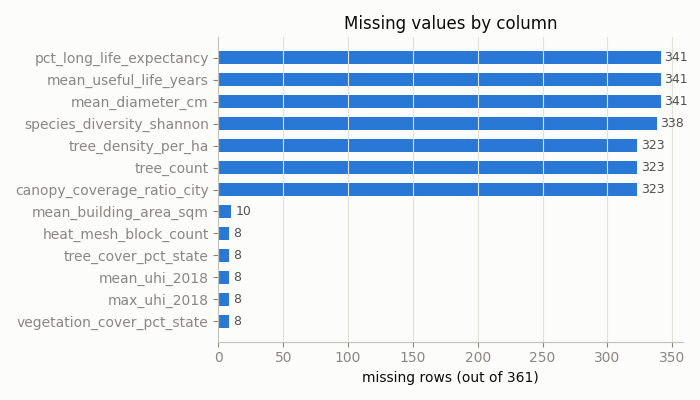

In [12]:
missing = features.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(missing.index, missing.values, color=BLUE, height=0.6)
for y, v in enumerate(missing.values):
    ax.text(v + 3, y, str(v), va="center", fontsize=9, color="#52514e")
ax.set_xlabel("missing rows (out of 361)")
ax.set_title("Missing values by column")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

In [13]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
area_sqkm,361.0,27.677457,77.855511,0.561494,4.181184,6.690936,13.353314,729.416420
tree_count,38.0,2159.578947,4897.134372,0.000000,0.000000,21.500000,2841.000000,28602.000000
tree_density_per_ha,38.0,9.300694,14.389927,0.000000,0.000000,0.058071,16.950967,70.644759
mean_diameter_cm,20.0,33.847131,7.361364,22.625000,27.214007,33.978257,39.239100,49.358560
species_diversity_shannon,23.0,2.837899,1.601610,-0.000000,2.240578,3.508437,3.983807,4.655031
pct_long_life_expectancy,20.0,0.331777,0.215213,0.000000,0.215563,0.249478,0.509580,0.826087
mean_useful_life_years,20.0,34.301278,3.643424,29.470180,31.861328,32.142044,36.290222,42.478261
canopy_coverage_ratio_city,38.0,0.059071,0.083852,0.000000,0.002337,0.012743,0.092387,0.384198
vegetation_cover_pct_state,353.0,36.422560,13.652591,5.330944,27.857490,34.044247,42.543357,76.405945
tree_cover_pct_state,353.0,12.664510,8.277812,0.836871,6.461062,10.959366,17.203566,47.597111


## 3. Feature distributions

Histograms for a representative feature from each group: vegetation, imperviousness,
built form, road network, parks, and the heat target itself. The dashed line marks the
median.

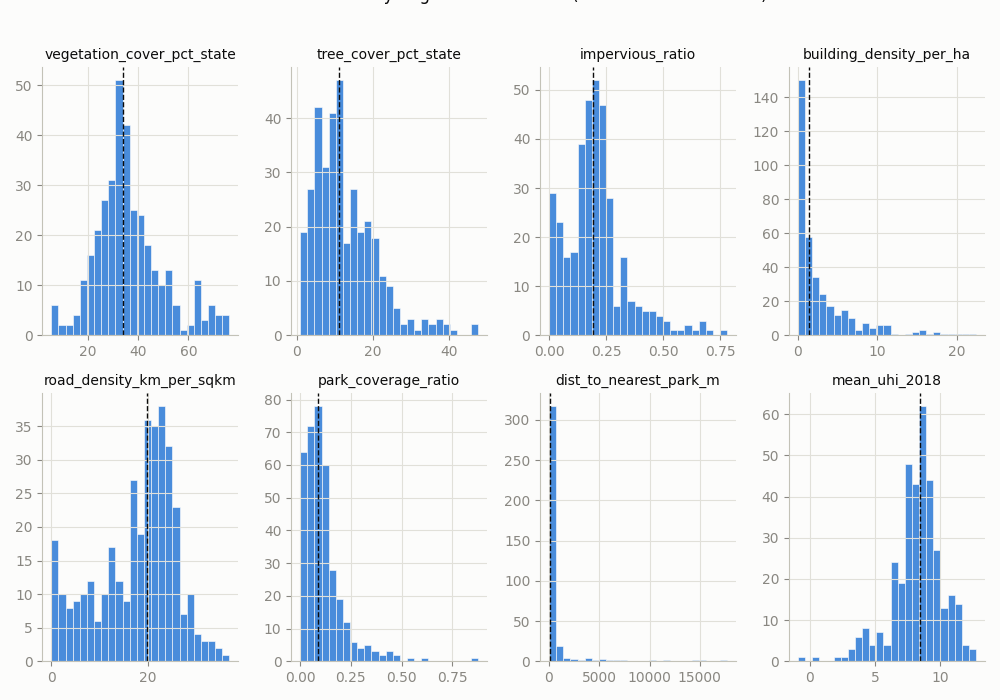

In [16]:
hist_cols = [
    "vegetation_cover_pct_state", "tree_cover_pct_state", "impervious_ratio",
    "building_density_per_ha", "road_density_km_per_sqkm", "park_coverage_ratio",
    "dist_to_nearest_park_m", "mean_uhi_2018",
]

fig, axes = plt.subplots(2, 4, figsize=(10, 7))
for ax, col in zip(axes.flat, hist_cols):
    data = features[col].dropna()
    ax.hist(data, bins=25, color=BLUE, alpha=0.85, edgecolor="#fcfcfb", linewidth=0.5)
    ax.set_title(col, fontsize=10)
    ax.axvline(data.median(), color="#0b0b0b", linewidth=1, linestyle="--")
fig.suptitle("Distributions of key engineered features (dashed line = median)", y=1.02)
fig.tight_layout()
plt.show()

## 4. How do features relate to each other, and to heat?

A correlation matrix over a curated set of engineered features (raw counts like
`tree_count` and `building_count` are excluded in favour of their density/ratio versions,
since those are what's actually comparable across SA2s of different sizes — see
`DAY_3.md` section A8).

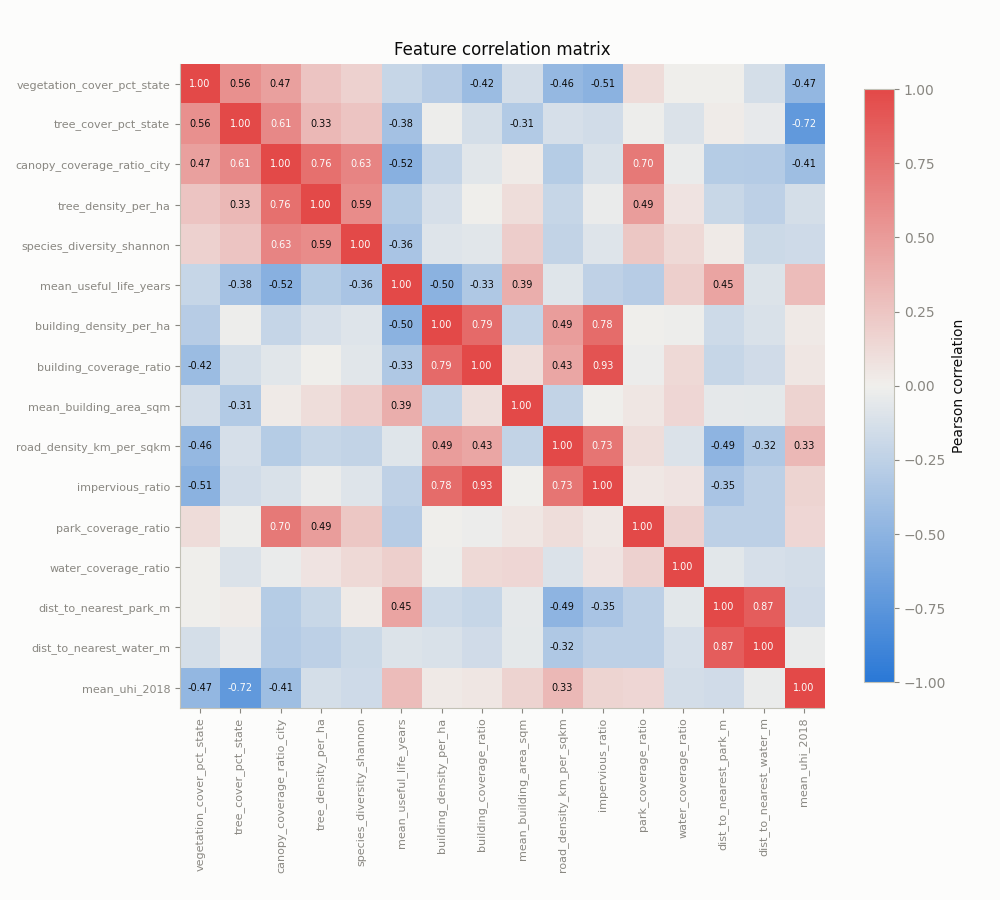

In [17]:
corr_cols = [
    "vegetation_cover_pct_state", "tree_cover_pct_state", "canopy_coverage_ratio_city",
    "tree_density_per_ha", "species_diversity_shannon", "mean_useful_life_years",
    "building_density_per_ha", "building_coverage_ratio", "mean_building_area_sqm",
    "road_density_km_per_sqkm", "impervious_ratio",
    "park_coverage_ratio", "water_coverage_ratio",
    "dist_to_nearest_park_m", "dist_to_nearest_water_m",
    "mean_uhi_2018",
]
corr = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)
ax.grid(False)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                     color="#fcfcfb" if abs(v) > 0.6 else "#0b0b0b")
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pearson correlation")
ax.set_title("Feature correlation matrix")
fig.tight_layout()
plt.show()

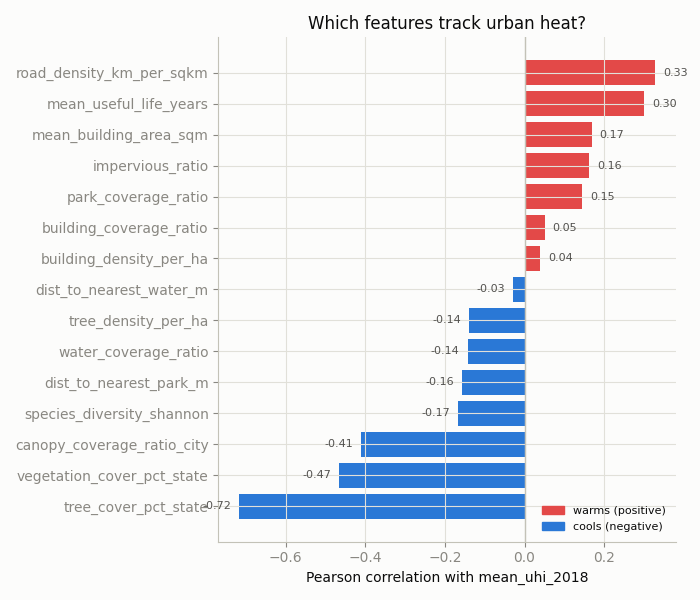

In [18]:
target_corr = corr["mean_uhi_2018"].drop("mean_uhi_2018").sort_values()
colors = [RED if v > 0 else BLUE for v in target_corr.values]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Pearson correlation with mean_uhi_2018")
ax.set_title("Which features track urban heat?")
for y, v in enumerate(target_corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), y, f"{v:.2f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=8, color="#52514e")
ax.legend(handles=[Patch(color=RED, label="warms (positive)"), Patch(color=BLUE, label="cools (negative)")],
          loc="lower right", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 5. Vegetation and impervious surface vs. heat

The two strongest single-feature relationships with `mean_uhi_2018`, plotted directly
with a linear trend line. `r` is the Pearson correlation shown in the matrix above.

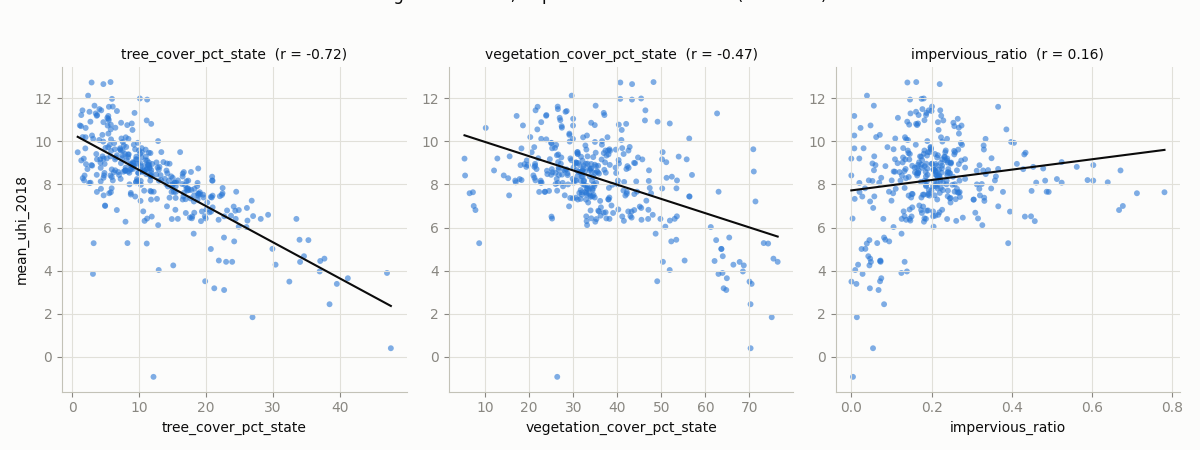

In [21]:
scatter_cols = ["tree_cover_pct_state", "vegetation_cover_pct_state", "impervious_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, col in zip(axes, scatter_cols):
    sub = features[[col, "mean_uhi_2018"]].dropna()
    ax.scatter(sub[col], sub["mean_uhi_2018"], s=18, color=BLUE, alpha=0.6, edgecolor="none")
    z = np.polyfit(sub[col], sub["mean_uhi_2018"], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color="#0b0b0b", linewidth=1.5)
    r = sub[col].corr(sub["mean_uhi_2018"])
    ax.set_title(f"{col}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel(col)
    if col == scatter_cols[0]:
        ax.set_ylabel("mean_uhi_2018")
fig.suptitle("Vegetation cools, impervious surface heats (SA2 level)", y=1.03)
fig.tight_layout()
plt.show()

## 6. Where is it hot, green, and paved?

Choropleth maps of the same three features across Greater Melbourne. Each uses its own
single-hue sequential ramp — warm/orange for heat (matching the domain convention),
green for vegetation, blue for imperviousness — so the "more is darker" reading is
intuitive within each panel; areas with no data are shown in light gray, not white,
so they're visually distinct from "very low value".

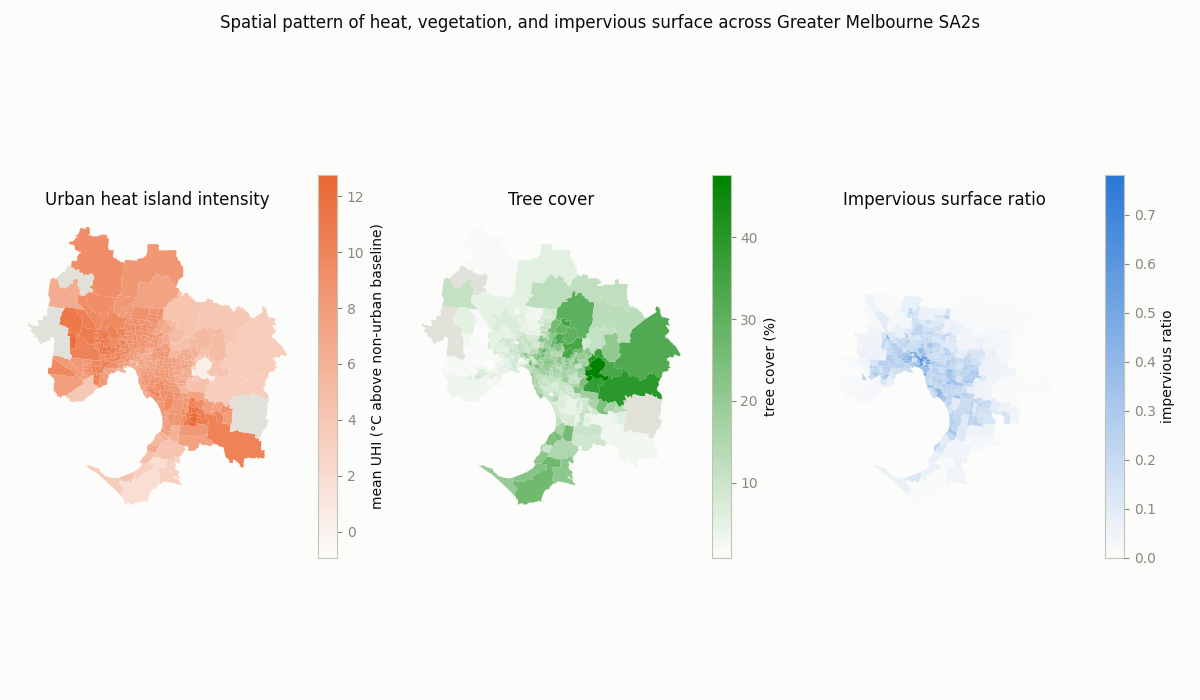

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 7))

heat_cmap = sequential_cmap(ORANGE, "heat")
green_cmap = sequential_cmap(GREEN, "green")
blue_cmap = sequential_cmap(BLUE, "blue")

gdf.plot(column="mean_uhi_2018", cmap=heat_cmap, legend=True, ax=axes[0],
         missing_kwds={"color": GRAY, "label": "no data"},
         legend_kwds={"label": "mean UHI (°C above non-urban baseline)", "shrink": 0.6})
axes[0].set_title("Urban heat island intensity")

gdf.plot(column="tree_cover_pct_state", cmap=green_cmap, legend=True, ax=axes[1],
         missing_kwds={"color": GRAY, "label": "no data"},
         legend_kwds={"label": "tree cover (%)", "shrink": 0.6})
axes[1].set_title("Tree cover")

gdf.plot(column="impervious_ratio", cmap=blue_cmap, legend=True, ax=axes[2],
         missing_kwds={"color": GRAY, "label": "no data"},
         legend_kwds={"label": "impervious ratio", "shrink": 0.6})
axes[2].set_title("Impervious surface ratio")

for ax in axes:
    ax.set_axis_off()
fig.suptitle("Spatial pattern of heat, vegetation, and impervious surface across Greater Melbourne SA2s", y=0.98)
fig.tight_layout()
plt.show()

## 7. Where does the City of Melbourne tree/canopy data actually cover?

An "emphasis" map, not a magnitude one: this is a binary in-coverage/out-of-coverage
split, so it uses one accent colour against gray context rather than a sequential ramp
(see `DAY_3.md` section C1 for why this gap exists and how it's handled).

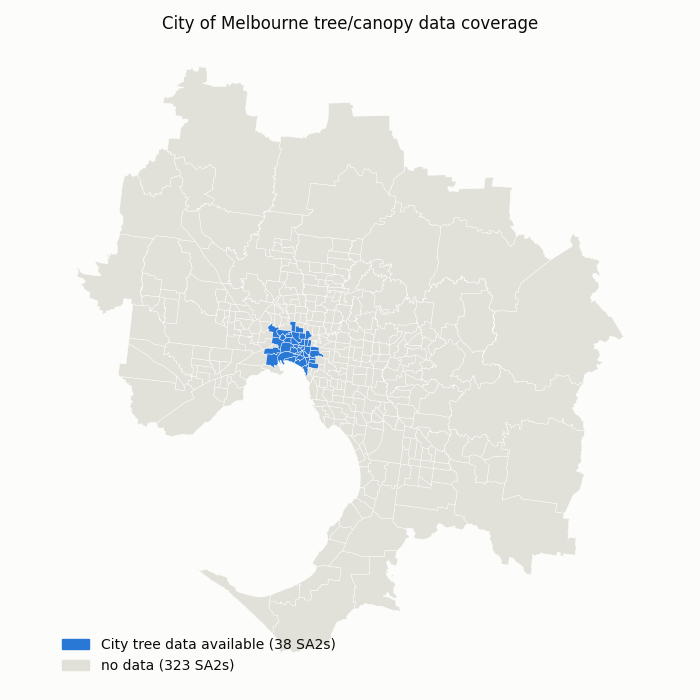

In [25]:
covered = gdf["tree_count"].notna()

fig, ax = plt.subplots(figsize=(7, 7))
gdf[~covered].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.3)
gdf[covered].plot(ax=ax, color=BLUE, edgecolor="white", linewidth=0.3)
ax.legend(
    handles=[
        Patch(color=BLUE, label=f"City tree data available ({covered.sum()} SA2s)"),
        Patch(color=GRAY, label=f"no data ({(~covered).sum()} SA2s)"),
    ],
    loc="lower left", frameon=False,
)
ax.set_title("City of Melbourne tree/canopy data coverage")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## 8. Hottest and coolest SA2s

A ranked table is the right form here — more than a handful of named areas is better
read as a table than decoded from a map legend.

In [26]:
cols = ["SA2_NAME21", "mean_uhi_2018", "tree_cover_pct_state", "impervious_ratio", "vegetation_cover_pct_state"]
ranked = features[cols].dropna(subset=["mean_uhi_2018"]).sort_values("mean_uhi_2018", ascending=False)

print("10 hottest SA2s (highest mean_uhi_2018):")
display(ranked.head(10).reset_index(drop=True))

print("\n10 coolest SA2s (lowest mean_uhi_2018):")
display(ranked.tail(10).sort_values("mean_uhi_2018").reset_index(drop=True))

10 hottest SA2s (highest mean_uhi_2018):


,SA2_NAME21,mean_uhi_2018,tree_cover_pct_state,impervious_ratio,vegetation_cover_pct_state
0,Cranbourne East - North,12.750776,5.736299,0.161787,48.232648
1,Cranbourne North - East,12.731282,2.912034,0.139718,40.696432
2,Cranbourne East - South,12.656278,4.671602,0.220249,43.363653
3,Cobblebank - Strathtulloh,12.120862,2.392285,0.038984,29.655278
4,Narre Warren South - West,11.988852,10.123002,0.180443,45.427413
5,Berwick - South West,11.971872,5.960776,0.175027,40.680856
6,Narre Warren South - East,11.938534,11.210190,0.146327,43.341130
7,Melton,11.655085,3.345791,0.056095,35.089633
8,Cairnlea,11.611842,6.070822,0.201006,26.482748
9,Sydenham,11.603489,5.497215,0.365743,21.923786



10 coolest SA2s (lowest mean_uhi_2018):


,SA2_NAME21,mean_uhi_2018,tree_cover_pct_state,impervious_ratio,vegetation_cover_pct_state
0,Kinglake,-0.931300,12.154971,0.004123,26.375136
1,Mount Dandenong - Olinda,0.396458,47.597111,0.054054,70.263166
2,Flinders,1.835686,26.941290,0.013784,75.059357
3,The Basin,2.438904,38.442967,0.081610,70.249454
4,Dromana,3.099290,22.700976,0.067849,64.743536
5,Hastings - Somers,3.178706,21.231469,0.046239,64.148707
6,Emerald - Cockatoo,3.383071,39.531755,0.012670,70.494043
7,Yarra Valley,3.489444,32.440145,0.000272,70.018295
8,Point Nepean,3.505607,19.873363,0.071573,49.068347
9,Montrose,3.645497,41.174768,0.074635,64.872755


## Takeaways

- **Vegetation cools, impervious surface warms** — `tree_cover_pct_state` (r ≈ -0.72) and
  `vegetation_cover_pct_state` (r ≈ -0.47) are the strongest negative correlates of
  `mean_uhi_2018`; `impervious_ratio` (r ≈ +0.16) is positive but weaker than expected,
  suggesting heat is driven more by *what's missing* (tree canopy) than by *what's
  present* (pavement) at the SA2 scale — plausible given SA2s are large, mixed-use areas.
- **The City of Melbourne tree/canopy features only cover ~10% of SA2s** (the inner LGA).
  They're useful supplementary signal for those suburbs but can't be relied on as a
  primary model feature across all of Greater Melbourne — `vegetation_cover_pct_state`
  (96% coverage) is the right primary vegetation feature for Day 4 modelling.
- **8 SA2s have no heat target at all** and will need to be dropped (or handled
  separately) when training a supervised model in Day 4, since there's nothing to predict
  for them.

See `DAY_3.md` for full methodology, data source details, and known limitations.